In [1]:
cd "C:\Users\Lenovo\Desktop\github projects\telcos customer churn"

C:\Users\Lenovo\Desktop\github projects\telcos customer churn


In [109]:
%%writefile src/ann_trainer.py

import os
import sys 
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense,Dropout,BatchNormalization)

from tensorflow.keras.callbacks import (EarlyStopping,ModelCheckpoint,ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report)

from src.exception import CustomException
from src.logger import logging

#DataClass

@dataclass
class ANNTrainerConfig:
     train_data_path = os.path.join("data","final","train_selected.csv")

     test_data_path = os.path.join("data","final","test_selected.csv")

     model_dir = os.path.join("artifacts","models")

     ann_model_path = os.path.join("artifacts","models","ann_model.keras")

     history_path = os.path.join( "reports","ann_training_history.csv")
    
     ann_report_path = os.path.join("reports","ann_model_report.csv")


class ANNTrainer:
    def __init__(self):
        self.config= ANNTrainerConfig()
        
        os.makedirs(self.config.model_dir,exist_ok=True)

        os.makedirs(os.path.dirname(self.config.history_path),exist_ok=True)

        logging.info("ANN Trainer initialized successfully.")


    def load_data(self):
        try:
            logging.info("Loading  train and test csv file for ANN")

            train_df=pd.read_csv(self.config.train_data_path)
            test_df=pd.read_csv(self.config.test_data_path)

            logging.info(f" train data shape{train_df.shape}")
            logging.info(f"test data shape{test_df.shape}")

            X_train=train_df.drop(columns=["Churn"],axis=1)
            y_train=train_df["Churn"]

            X_test=test_df.drop(columns=["Churn"],axis=1)
            y_test=test_df["Churn"]

            return X_train,X_test,y_train,y_test

        except Exception as e:
            raise CustomException(e, sys)


    def prepare_training_data(self,X_train,y_train):
        try:
            logging.info("Applying SMOTE to cure imbalance")

            smote=SMOTE(random_state=42)

            X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

            logging.info(f"Shape after applying SMOTE {X_train_smote.shape}")

            logging.info("Creating Validation dataset for ANN  on SMOTE dataset")

            X_train_final,X_val,y_train_final,y_val=train_test_split(X_train_smote,y_train_smote,test_size=0.2,
                                                                     random_state=42,stratify=y_train_smote)

            logging.info(f"Training Data shape:{X_train_final.shape}")
            logging.info(f" Validataon shape:{X_val.shape}")
            
            return (X_train_final,X_val,y_train_final,y_val)

        except Exception as e:
            raise CustomException(e, sys)


    def build_ann_model(self,input_dim):
        try:
            logging.info("Building ANN MODEL")

            model=Sequential([
                # first layer input+hidden

                Dense(units=64,activation="relu",input_shape=(input_dim,)),
                BatchNormalization(),
                Dropout(0.3),

                #hidden layer 2 
                Dense(units=32,activation="relu"),
                BatchNormalization(),
                Dropout(0.2),

                #output layer
                Dense(units=1,activation="sigmoid")])

            #compile model
            model.compile(optimizer= Adam(learning_rate=0.001),loss="binary_crossentropy",metrics=["accuracy"])
            logging.info("Model Created sucessfully")

            return model
        except Exception as e:
            raise CustomException(e, sys)

    def train_ann_model(self,model,X_train,y_train,X_val,y_val):
        try:
            logging.info("Starting Training")
            #early stopping
            early_stopping = EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True,verbose=1)

        # ---------------- Save Best Model ----------------
            checkpoint = ModelCheckpoint(filepath=self.config.ann_model_path,monitor="val_loss",save_best_only=True,verbose=1)
            #reduce lr rate
            reduce_lr = ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=5,min_lr=1e-6,verbose=1)

            start_time=time.time()

            history=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=40,batch_size=32,callbacks=[early_stopping,checkpoint,reduce_lr],
            verbose=1)

            end_time=time.time()

            training_time = round(end_time - start_time, 2)

            logging.info(f"training completed in {training_time} seconds.")

            return history, training_time

        except Exception as e:
            raise CustomException(e, sys)


    def evaluate_ann_model(self,model,history,training_time,X_test,y_test):
        try:
            logging.info("Model Evaluation")

            y_prob=model.predict(X_test,verbose=0).flatten()
            y_pred=(y_prob>=0.5).astype(int)

            #metrics

            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            roc_auc = roc_auc_score(y_test, y_prob)
            class_report=classification_report(y_test,y_pred)

            #training history 
            history_df=pd.DataFrame(history.history)
            history_df.to_csv(self.config.history_path,index=False)

            logging.info("ANN training history saved successfully.")

            # Ann Report 
            ann_results=pd.DataFrame([{"Model": "ANN",
            "Accuracy": round(accuracy, 4),"Precision": round(precision, 4),
            "Recall": round(recall, 4),"F1 Score": round(f1, 4),
            "ROC AUC": round(roc_auc, 4),"Training Time (Seconds)": training_time}])

            ann_results.to_csv(self.config.ann_report_path,index=False)
            
            logging.info("ANN evaluation completed successfully.")

            return ann_results, history_df

        except Exception as e:
            raise CustomException(e, sys)

                                    



            




      
            
        






            
            

            
            
    




Overwriting src/ann_trainer.py


In [110]:
import importlib
import src.ann_trainer as ann_trainer   # your .py file

importlib.reload(ann_trainer)

<module 'src.ann_trainer' from 'C:\\Users\\Lenovo\\Desktop\\github projects\\telcos customer churn\\src\\ann_trainer.py'>

In [111]:
from src.ann_trainer import ANNTrainer

In [112]:
ann_trainer=ANNTrainer()

In [87]:
X_train,X_test,y_train,y_test= ann_trainer.load_data()

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (5634, 45)
X_test  : (1409, 45)
y_train : (5634,)
y_test  : (1409,)


In [88]:
X_train_final,X_val,y_train_final,y_val=ann_trainer.prepare_training_data(X_train,y_train)

print("Training Shape   :", X_train_final.shape)
print("Validation Shape :", X_val.shape)

Training Shape   : (6622, 45)
Validation Shape : (1656, 45)


In [89]:
import pandas as pd

print("Training Distribution After SMOTE")
print(pd.Series(y_train_final).value_counts())

print("\nValidation Distribution")
print(pd.Series(y_val).value_counts())

Training Distribution After SMOTE
Churn
0    3311
1    3311
Name: count, dtype: int64

Validation Distribution
Churn
1    828
0    828
Name: count, dtype: int64


In [90]:
model=ann_trainer.build_ann_model(input_dim=X_train_final.shape[1])

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [91]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 192 (768.00 B)

In [92]:
history, ann_training_time = ann_trainer.train_ann_model(
    model=model,
    X_train=X_train_final,
    y_train=y_train_final,
    X_val=X_val,
    y_val=y_val
)

print("ANN Training Time:", ann_training_time, "seconds")

Epoch 1/40
199/207 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6838 - loss: 0.6420
Epoch 1: val_loss improved from None to 0.49899, saving model to artifacts\models\ann_model.keras

Epoch 1: finished saving model to artifacts\models\ann_model.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7253 - loss: 0.5818 - val_accuracy: 0.7645 - val_loss: 0.4990 - learning_rate: 0.0010
Epoch 2/40
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7577 - loss: 0.5163
Epoch 2: val_loss improved from 0.49899 to 0.48289, saving model to artifacts\models\ann_model.keras

Epoch 2: finished saving model to artifacts\models\ann_model.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7539 - loss: 0.5145 - val_accuracy: 0.7609 - val_loss: 0.4829 - learning_rate: 0.0010
Epoch 3/40
201/207 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7565 - loss: 0.5096
Epoch 3: val_loss improved from 0.48289 to 0.47359, saving model to artifacts\models\ann_model.keras

Epoch 3: finished savi

In [93]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

In [115]:
ann_results_df, history_df = ann_trainer.evaluate_ann_model(
    model=model,
    history=history,
    training_time=ann_training_time,
    X_test=X_test,
    y_test=y_test
)

from IPython.display import display

display(ann_results_df)
display(history_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (Seconds)
0,ANN,0.7587,0.532,0.7567,0.6247,0.8245,76.33


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.725310,0.581763,0.764493,0.498993,0.0010
1,0.753851,0.514468,0.760870,0.482893,0.0010
2,0.761854,0.499757,0.770531,0.473590,0.0010
3,0.770764,0.483433,0.779589,0.463455,0.0010
4,0.767291,0.489004,0.783816,0.461926,0.0010
5,0.778919,0.474605,0.780193,0.456288,0.0010
6,0.773482,0.472978,0.786232,0.453324,0.0010
7,0.777409,0.464426,0.789855,0.454233,0.0010
8,0.783902,0.460250,0.784420,0.450427,0.0010
9,0.783902,0.462331,0.793478,0.448013,0.0010


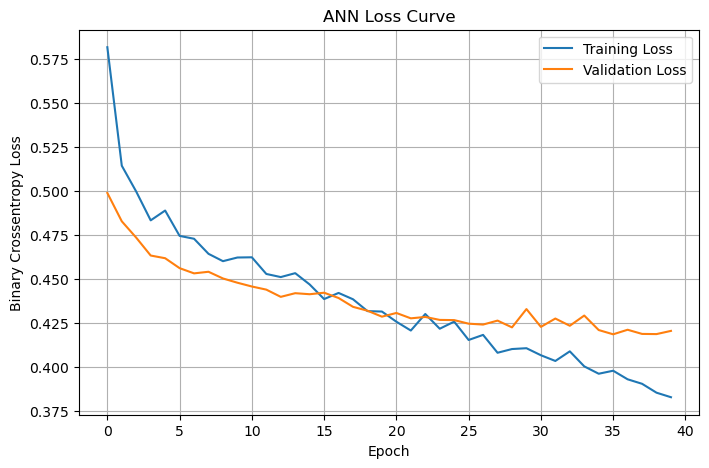

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_df["loss"],label="Training Loss")

plt.plot(history_df["val_loss"],label="Validation Loss")

plt.title("ANN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.grid(True)

save_path = rf"C:\Users\Lenovo\Desktop\github projects\telcos customer churn\reports\ANN_Loss_Curve.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

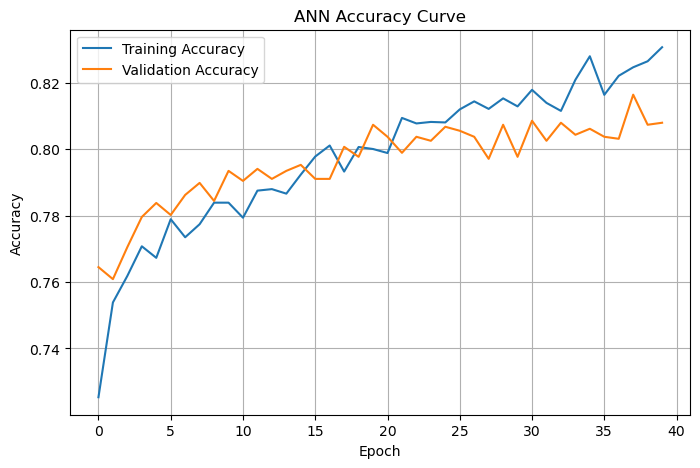

In [118]:
plt.figure(figsize=(8,5))

plt.plot(
    history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ANN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

save_path = rf"C:\Users\Lenovo\Desktop\github projects\telcos customer churn\reports\ANN_Accuracy_Curve.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()